# ΘSTM Kaggle — OBMM/ΘBMM Soft‑Routing + Wider Messages

This notebook keeps the **best-performing v27.7 mechanism**:

- **ΘBMM-soft**: bilinear **4-neighbor** soft routing on a 2D grid (trainable topology)
- **counts-gated EMA** state updates (mass-aware so soft routing doesn't collapse into noise)
- same fair training loop + speed microbench vs dense SDPA (qkv)

### Why v27.9?

v27.7 gave us a strong **long-context speedup** (≈1.3× at T=1024) but still a small quality gap (best_val ≈ 1.546 vs SDPA ≈ 1.50).

v27.8 tried to “spend” the speed margin on **extra depth**, but that **did not improve validation loss** and mostly removed the speed advantage.

**Hypothesis for v27.9:** the remaining gap is dominated by an *information bottleneck* inside the bucket memory:
`msg_dim=24` is a low-rank channel compared to `head_dim=64`.

So in v27.9 we **keep depth fixed** (6 layers) and instead **widen the memory channel** (`msg_dim`) while preserving the same soft routing + counts-gated update.


In [1]:

import os, math, time, random, contextlib
from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

VERSION = "v27.11"  # <-- bump this each experiment iteration
print("VERSION:", VERSION)


def seed_everything(seed: int = 1337):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(1337)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__)


def get_amp(device: str):
    # Returns (autocast_ctx_factory, grad_scaler_or_None)
    if device != "cuda":
        return (lambda: contextlib.nullcontext()), None

    try:
        scaler = torch.amp.GradScaler("cuda")

        def autocast():
            return torch.amp.autocast(device_type="cuda", dtype=torch.float16)

        return autocast, scaler
    except Exception:
        scaler = torch.cuda.amp.GradScaler()

        def autocast():
            return torch.cuda.amp.autocast(dtype=torch.float16)

        return autocast, scaler


VERSION: v27.11
device: cuda
torch: 2.8.0+cu126


In [2]:

# Tiny Shakespeare (Kaggle-friendly)
# Tries Kaggle dataset path first; otherwise downloads.

import pathlib


def load_text() -> str:
    candidates = [
        "/kaggle/input/tinyshakespeare/input.txt",
        "/kaggle/input/tinyshakespeare/tinyshakespeare.txt",
        "./data/tinyshakespeare.txt",
        "./tinyshakespeare.txt",
    ]
    for p in candidates:
        if os.path.exists(p):
            print("Loading:", p)
            return pathlib.Path(p).read_text(encoding="utf-8")

    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    try:
        import requests

        print("Downloading:", url)
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        return r.text
    except Exception as e:
        print("Download failed:", repr(e))
        fallback = ("To be, or not to be, that is the question.\n" * 10000)
        print("Using fallback text (place ./data/tinyshakespeare.txt for the full dataset).")
        return fallback


text = load_text()
print("chars:", len(text))
print(text[:200])


Downloading: https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
chars: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [3]:

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}


def encode(s: str):
    return [stoi[c] for c in s]


def decode(ids):
    return "".join([itos[i] for i in ids])


data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("vocab_size:", vocab_size)
print("train tokens:", train_data.numel(), "val tokens:", val_data.numel())


vocab_size: 65
train tokens: 1003854 val tokens: 111540


In [4]:


def get_batch(split: str, batch_size: int, block_size: int, device: str):
    d = train_data if split == "train" else val_data
    ix = torch.randint(0, len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i : i + block_size] for i in ix])
    y = torch.stack([d[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


@torch.no_grad()
def estimate_loss(model, eval_iters: int, batch_size: int, block_size: int, device: str):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split, batch_size, block_size, device)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


def loss_to_ppl(loss: float) -> float:
    return float(math.exp(min(20.0, loss)))



## What we are optimizing (practical target)

We’re not chasing a single magic loss number in isolation — we’re chasing a **frontier**:

- **Quality:** validation loss close to dense SDPA (FlashAttention/SDPA baseline)
- **Efficiency:** lower *time per step* and better *scaling with context length* (ideally closer to O(T) than O(T²))

On Tiny Shakespeare at block_size=128, dense SDPA is already extremely optimized, so the real win usually shows up at **longer contexts** (512–1024+).

That’s why every notebook includes:

- train/val loss curves
- and a speed microbenchmark across T = 128, 256, 512, 1024


In [5]:

# =====================================================
# Model: GPT + ΘBMM + ΘBMM-HiLoExp (v27.11)
# - Fix: edge_drop now ONLY applies during training (eval is deterministic)
# - Fix: multi-hash rotations are precomputed (no per-forward randomness)
# - Speed: reuse per-chunk scatter buffers (sums/counts) instead of realloc
# - Speed: precompute coarse ids for HiLoExp outside the chunk loop
# =====================================================

import math
from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F


# -----------------------------
# Helpers
# -----------------------------

def orthogonalize(mats: torch.Tensor, iters: int = 4) -> torch.Tensor:
    """Cheap orthogonalization for small 2x2 rotations."""
    x = mats
    for _ in range(iters):
        y = x
        y = y / (y.norm(dim=(-2, -1), keepdim=True) + 1e-8)
        i = torch.eye(y.size(-1), device=y.device, dtype=y.dtype)[None]
        for _ in range(2):
            y = 0.5 * y @ (3 * i - (y.transpose(-1, -2) @ y))
        x = y
    return x


def _logit(p: float) -> float:
    p = float(min(0.9999, max(1e-4, p)))
    return math.log(p / (1.0 - p))


# -----------------------------
# Config
# -----------------------------
@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int

    n_layers: int = 6
    n_heads: int = 8
    head_dim: int = 64
    dropout: float = 0.1

    # mixer selection
    attn_type: str = "theta_bmm_hilo"  # "qkv" | "theta_bmm" | "theta_bmm_hilo"

    # ΘBMM knobs
    msg_dim: int = 16
    conv_kernel: int = 31
    routing_dim: int = 2
    grid_size: int = 32
    n_hashes: int = 1
    chunk_size: int = 64

    edge_drop: float = 0.2
    route_drop: float = 0.0
    gamma_init: float = 0.25
    token_alpha: bool = True
    stopgrad_topology: bool = True
    detach_counts: bool = True

    mem_drop: float = 0.0  # dropout on retrieved bucket memory

    write_drop: float = 0.0  # dropout on write message vectors

    # v27: deterministic multi-hash
    hash_seed: int = 1337

    # HiLoExp (hierarchical memory + coarse expander mixing)
    hilo_ratio: int = 2
    hilo_beta_init: float = 0.25  # initial coarse-read weight β

    coarse_mix: bool = True
    coarse_degree: int = 2
    coarse_eps_init: float = 0.12
    coarse_eps_max: float = 0.25
    coarse_steps: int = 1

    # speed knobs
    coarse_update_every: int = 1  # refresh coarse state every N chunks (1 = every chunk)
    hilo_layers: Optional[int] = None  # None=all layers HiLo, 0=none, k=last k layers use HiLo

    @property
    def n_embed(self) -> int:
        return self.n_heads * self.head_dim


# -----------------------------
# Routing: bucketize
# -----------------------------

def _to_bucket(rx: torch.Tensor, ry: torch.Tensor, grid_size: int) -> torch.Tensor:
    # rx,ry in [-1,1] ideally
    rx = rx.clamp(-1.0, 1.0)
    ry = ry.clamp(-1.0, 1.0)
    gx = ((rx + 1.0) * 0.5 * (grid_size - 1)).round().long().clamp(0, grid_size - 1)
    gy = ((ry + 1.0) * 0.5 * (grid_size - 1)).round().long().clamp(0, grid_size - 1)
    return gy * grid_size + gx


def bucketize(x: torch.Tensor, proj: nn.Linear, grid_size: int, n_hashes: int, rots: Optional[torch.Tensor] = None) -> torch.Tensor:
    """Hard bucket assignment.

    x: (B,H,T,C)
    returns ids: (B,H,T,n_hashes) in [0, n_hashes*grid_size*grid_size)

    v27 fix: if n_hashes>1, rotations must be provided (precomputed in module).
    """
    B, H, T, C = x.shape
    u = proj(x)  # (B,H,T,2)
    u = torch.tanh(u)

    rx, ry = u[..., 0], u[..., 1]

    if n_hashes == 1:
        ids0 = _to_bucket(rx, ry, grid_size)
        return ids0[..., None]

    if rots is None:
        raise ValueError("bucketize: n_hashes>1 requires precomputed rots (v27.9)")

    # rots: (H, n_hashes, 2,2)
    xy = torch.stack([rx, ry], dim=-1).to(torch.float32)  # (B,H,T,2)
    outs = []
    for h in range(n_hashes):
        R = rots[:, h].to(xy.device, dtype=xy.dtype)  # (H,2,2)
        rot = torch.einsum("bhtd,hde->bhte", xy, R)
        ids_h = _to_bucket(rot[..., 0], rot[..., 1], grid_size)
        outs.append(ids_h + h * (grid_size * grid_size))
    return torch.stack(outs, dim=-1)



# -----------------------------
# Routing: SOFT bucketize (bilinear 4-neighbor)
# -----------------------------
def bucketize_soft(
    x: torch.Tensor,
    proj: nn.Linear,
    grid_size: int,
    n_hashes: int,
    rots: Optional[torch.Tensor] = None,
):
    '''
    Soft (differentiable) 2D grid routing.

    For each token we produce continuous (cx,cy) in [0, grid_size-1] and
    bilinearly distribute to the 4 neighboring buckets:
      (x0,y0), (x1,y0), (x0,y1), (x1,y1)

    Returns:
      ids:  (B,H,T,n_hashes,4)   long bucket ids in [0, n_hashes*grid_size^2)
      wts:  (B,H,T,n_hashes,4)   float weights, sum=1 over the last dim
    '''
    B, H, T, _ = x.shape

    y = proj(x).float()
    y = torch.tanh(y)

    if rots is None:
        if n_hashes > 1:
            raise ValueError("bucketize_soft: n_hashes>1 requires precomputed rots (v27.9)")
    elif rots.ndim != 4:
        raise ValueError(f"bucketize_soft: expected rots with ndim=4, got {rots.ndim}")

    ids_all = []
    wts_all = []
    for h in range(n_hashes):
        if rots is not None:
            yy = torch.einsum("bhtd,hde->bhte", y, rots[:, h])  # (B,H,T,2)
        else:
            yy = y

        rx = yy[..., 0].clamp(-1.0, 1.0)
        ry = yy[..., 1].clamp(-1.0, 1.0)

        cx = (rx + 1.0) * 0.5 * (grid_size - 1)
        cy = (ry + 1.0) * 0.5 * (grid_size - 1)

        x0 = torch.floor(cx)
        y0 = torch.floor(cy)
        x1 = (x0 + 1).clamp(max=grid_size - 1)
        y1 = (y0 + 1).clamp(max=grid_size - 1)

        wx1 = (cx - x0)
        wy1 = (cy - y0)
        wx0 = 1.0 - wx1
        wy0 = 1.0 - wy1

        x0l = x0.long()
        x1l = x1.long()
        y0l = y0.long()
        y1l = y1.long()

        id00 = y0l * grid_size + x0l
        id01 = y0l * grid_size + x1l
        id10 = y1l * grid_size + x0l
        id11 = y1l * grid_size + x1l

        off = h * (grid_size * grid_size)
        id00 = id00 + off
        id01 = id01 + off
        id10 = id10 + off
        id11 = id11 + off

        w00 = wx0 * wy0
        w01 = wx1 * wy0
        w10 = wx0 * wy1
        w11 = wx1 * wy1

        ids_h = torch.stack([id00, id01, id10, id11], dim=-1)  # (B,H,T,4)
        wts_h = torch.stack([w00, w01, w10, w11], dim=-1)      # (B,H,T,4)

        ids_all.append(ids_h)
        wts_all.append(wts_h)

    ids = torch.stack(ids_all, dim=3)  # (B,H,T,n_hashes,4)
    wts = torch.stack(wts_all, dim=3)  # (B,H,T,n_hashes,4)
    return ids, wts

# -----------------------------
# ΘBMM mixers
# -----------------------------

class ThetaBucketMemoryMixer(nn.Module):
    """Plain ΘBMM (no coarse hierarchy)."""

    def __init__(self, cfg: GPTConfig, *, hash_seed: int):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.head_dim = cfg.head_dim
        self.msg_dim = cfg.msg_dim
        self.grid_size = cfg.grid_size
        self.n_hashes = cfg.n_hashes
        self.chunk_size = cfg.chunk_size
        self.edge_drop = float(cfg.edge_drop)
        self.stopgrad_topology = bool(cfg.stopgrad_topology)
        self.detach_counts = bool(getattr(cfg, "detach_counts", True))
        self.route_drop = float(getattr(cfg, "route_drop", 0.0))
        self.mem_drop = float(getattr(cfg, "mem_drop", 0.0))
        self.write_drop = float(getattr(cfg, "write_drop", 0.0))

        n_embed = cfg.n_embed
        H, D, Dm = cfg.n_heads, cfg.head_dim, cfg.msg_dim

        self.routing_proj = nn.Linear(D, cfg.routing_dim, bias=False)
        self.val_proj = nn.Linear(D, Dm, bias=False)
        self.msg_proj = nn.Linear(D, Dm, bias=False)

        # depthwise causal conv on message stream
        k = int(cfg.conv_kernel)
        self.local_conv = nn.Conv1d(Dm, Dm, kernel_size=k, padding=k - 1, groups=Dm, bias=False)

        # learnable EMA update rate and read scaling
        self.gamma = nn.Parameter(torch.tensor(_logit(cfg.gamma_init), dtype=torch.float32))
        self.read_scale = nn.Parameter(torch.ones(H, 1, 1, dtype=torch.float32))

        self.alpha_proj = nn.Linear(D, 1, bias=False) if cfg.token_alpha else None
        self.out_proj = nn.Linear(H * Dm, n_embed, bias=False)

        # v27: precompute hash rotations (no per-forward randomness)
        self.register_buffer("hash_rots", None, persistent=False)
        if cfg.n_hashes > 1:
            g = torch.Generator(device="cpu")
            g.manual_seed(int(hash_seed))
            mats = torch.randn(H, cfg.n_hashes, 2, 2, generator=g, dtype=torch.float32)
            mats = orthogonalize(mats.view(-1, 2, 2)).view(H, cfg.n_hashes, 2, 2)
            self.hash_rots = mats

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B,T,C)
        B, T, C = x.shape
        H, D, Dm = self.n_heads, self.head_dim, self.msg_dim
        gs, nh = self.grid_size, self.n_hashes
        M = nh * gs * gs

        q = x.view(B, T, H, D).transpose(1, 2)  # (B,H,T,D)
        u = q.detach() if self.stopgrad_topology else q
        ids = bucketize(u, self.routing_proj, grid_size=gs, n_hashes=nh, rots=self.hash_rots)  # (B,H,T,nh)

        v = self.val_proj(q)  # (B,H,T,Dm)

        # local conv message
        loc = self.msg_proj(q)  # (B,H,T,Dm)
        loc2 = loc.reshape(B * H, T, Dm).transpose(1, 2)  # (BH,Dm,T)
        loc2 = self.local_conv(loc2)[..., :T]
        loc = loc2.transpose(1, 2).reshape(B, H, T, Dm)

        alpha = None
        if self.alpha_proj is not None:
            alpha = torch.sigmoid(self.alpha_proj(q)).squeeze(-1)  # (B,H,T)

        # recurrent state (built fresh per forward)
        state = torch.zeros((B, H, M, Dm), device=x.device, dtype=torch.float32)

        # v27 speed: reuse scatter buffers per chunk
        sums = torch.zeros((B, H, M, Dm), device=x.device, dtype=torch.float32)
        counts = torch.zeros((B, H, M), device=x.device, dtype=torch.float32)

        outs = []
        gamma = torch.sigmoid(self.gamma)  # scalar
        read_scale = self.read_scale.to(v.dtype)

        for t0 in range(0, T, self.chunk_size):
            t1 = min(T, t0 + self.chunk_size)
            Tc = t1 - t0

            # read
            ids_c = ids[:, :, t0:t1]  # (B,H,Tc,nh)
            ids_flat = ids_c.reshape(B, H, Tc * nh)
            idx = ids_flat[:, :, :, None].expand(B, H, Tc * nh, Dm)

            mem = state.gather(2, idx).view(B, H, Tc, nh, Dm).mean(dim=3)  # (B,H,Tc,Dm)
            if self.training and self.mem_drop > 0:
                mem = F.dropout(mem, p=self.mem_drop, training=True)
            y = loc[:, :, t0:t1] + (read_scale * mem)
            if alpha is not None:
                y = y * alpha[:, :, t0:t1].unsqueeze(-1)
            outs.append(y)

            # write
            wr = v[:, :, t0:t1]  # (B,H,Tc,Dm)
            if self.training and self.write_drop > 0:
                wr = F.dropout(wr, p=self.write_drop, training=True)
            if self.training and self.edge_drop > 0:
                mask = (torch.rand((B, 1, Tc, 1), device=x.device) > self.edge_drop).to(wr.dtype)
                wr = wr * mask

            sums.zero_(); counts.zero_()
            src = wr[:, :, :, None, :].expand(B, H, Tc, nh, Dm).reshape(B, H, Tc * nh, Dm)
            sums.scatter_add_(2, idx, src.to(torch.float32))

            ones = torch.ones((B, H, Tc * nh), device=x.device, dtype=torch.float32)
            counts.scatter_add_(2, ids_flat, ones)

            denom = counts.clamp_min(1.0)[..., None]
            msg_mean = sums / denom
            has = (counts > 0).to(torch.float32)[..., None]

            # EMA update
            state = state * (1.0 - gamma * has) + gamma * msg_mean * has

        y = torch.cat(outs, dim=2)  # (B,H,T,Dm)
        y = y.transpose(1, 2).contiguous().view(B, T, H * Dm)
        return self.out_proj(y)


# =====================================================
# ΘBMM / OBMM (SOFT routing variant)
# - bilinear 4-neighbor soft assignment per token
# - gradients flow into the routing projection (learnable topology)
# =====================================================
class ThetaBucketMemoryMixerSoft(ThetaBucketMemoryMixer):
    """Soft 4-neighbor routing variant of ΘBMM (OBMM).

    Keeps the same parameters as ThetaBucketMemoryMixer (val_proj/msg_proj/routing_proj/etc),
    but replaces hard bucket assignment with bilinear (4-neighbor) soft assignment on a 2D grid.

    Notes:
      - Routing weights are differentiable; set cfg.stopgrad_topology=False to allow gradients
        into routing_proj.
      - Complexity remains ~O(T) in sequence length (scatter/gather over buckets).
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        H = self.n_heads
        D = self.head_dim
        Dm = self.msg_dim
        gs = self.grid_size
        nh = self.n_hashes
        K = 4

        # Total routing buckets across hashes
        M = nh * gs * gs

        device = x.device
        dtype = x.dtype

        # Q per head (no learned QKV projections; matches ΘBMM)
        q = x.view(B, T, H, D).transpose(1, 2)  # (B,H,T,D)

        # Local path (depthwise conv over message dims)
        loc = self.msg_proj(q)  # (B,H,T,Dm)
        loc = loc.transpose(2, 3).reshape(B * H, Dm, T)  # (B*H,Dm,T)
        loc = self.local_conv(loc)[..., :T]
        loc = loc.view(B, H, Dm, T).transpose(2, 3).contiguous()  # (B,H,T,Dm)

        # Values for memory writes
        v = self.val_proj(q)  # (B,H,T,Dm)

        # Routing input (optionally stop gradients)
        u = q.detach() if self.stopgrad_topology else q

        # Soft bucket ids + weights
        # ids, wts: (B,H,T,nh,4)
        ids, wts = bucketize_soft(u, self.routing_proj, gs, nh, rots=self.hash_rots)

        # Memory state (float32 for stability)
        state = torch.zeros(B, H, M, Dm, device=device, dtype=torch.float32)

        # Reusable per-chunk buffers
        sums = torch.zeros(B, H, M, Dm, device=device, dtype=torch.float32)
        counts = torch.zeros(B, H, M, device=device, dtype=torch.float32)

        gamma = torch.sigmoid(self.gamma).to(torch.float32)  # scalar
        read_scale = self.read_scale.to(torch.float32)        # (H,1,1)

        collect = bool(getattr(self, "collect_stats", False))
        if collect:
            ent_sum = torch.zeros((), device=device, dtype=torch.float32)
            util_sum = torch.zeros((), device=device, dtype=torch.float32)
            max_sum = torch.zeros((), device=device, dtype=torch.float32)
            gmean_sum = torch.zeros((), device=device, dtype=torch.float32)
            n_chunks = 0

        y_chunks = []
        chunk = int(self.chunk_size)

        for t0 in range(0, T, chunk):
            t1 = min(T, t0 + chunk)
            Tc = t1 - t0

            idc = ids[:, :, t0:t1]  # (B,H,Tc,nh,K)
            wtc = wts[:, :, t0:t1].to(torch.float32)  # (B,H,Tc,nh,K)
            wtc_read = wtc
            if self.training and self.route_drop > 0:
                # Drop some routing edges on READ (attention-style edge dropout), then renormalize.
                mask = (torch.rand_like(wtc_read) > self.route_drop).to(wtc_read.dtype)
                wtc_d = wtc_read * mask
                sumw = wtc_d.sum(dim=-1, keepdim=True)
                wtc_read = torch.where(sumw > 0, wtc_d / sumw.clamp_min(1e-6), wtc_read)

            if collect:
                p = wtc_read.clamp_min(1e-8)
                ent_sum += (-(p * p.log()).sum(dim=-1)).mean()
                n_chunks += 1

            # -----------------------------
            # READ (from previous state)
            # -----------------------------
            idx = idc.reshape(B, H, Tc * nh * K, 1).expand(B, H, Tc * nh * K, Dm)  # (B,H,*,Dm)
            mem = state.gather(2, idx).view(B, H, Tc, nh, K, Dm)
            mem = (mem * wtc_read.unsqueeze(-1)).sum(dim=4)  # sum over 4 neighbors -> (B,H,Tc,nh,Dm)
            mem = mem.mean(dim=3)  # mean over hashes -> (B,H,Tc,Dm)

            if self.training and self.mem_drop > 0:
                mem = F.dropout(mem, p=self.mem_drop, training=True)

            loc_c = loc[:, :, t0:t1].to(torch.float32)  # (B,H,Tc,Dm)
            y = loc_c + read_scale * mem

            # Optional token-wise gate
            if self.alpha_proj is not None:
                alpha = torch.sigmoid(self.alpha_proj(q[:, :, t0:t1]).to(torch.float32))  # (B,H,Tc,1)
                y = y * alpha

            y_chunks.append(y.to(dtype))

            # -----------------------------
            # WRITE (update state after reading)
            # -----------------------------
            wr = v[:, :, t0:t1].to(torch.float32)  # (B,H,Tc,Dm)
            if self.training and self.write_drop > 0:
                wr = F.dropout(wr, p=self.write_drop, training=True)


            if self.training and self.edge_drop > 0:
                keep = (torch.rand(B, 1, Tc, 1, device=device) > self.edge_drop).to(torch.float32)
                wtc = wtc * keep.unsqueeze(3)  # broadcast over nh,K

            # Weighted write contribution per (token,hash,neighbor)
            src = (wr.unsqueeze(3).unsqueeze(3) * wtc.unsqueeze(-1)).reshape(B, H, Tc * nh * K, Dm)

            wtc_counts = wtc.detach() if self.detach_counts else wtc

            if self.detach_counts:
                sums.zero_(); counts.zero_()
            else:
                # Reset buffers (autograd-safe: allocate fresh tensors per chunk)
                sums = torch.zeros_like(sums)
                counts = torch.zeros_like(counts)

            # Accumulate into buckets
            sums.scatter_add_(2, idx, src)
            counts.scatter_add_(2, idc.reshape(B, H, Tc * nh * K), wtc_counts.reshape(B, H, Tc * nh * K))

            # Weighted average update; epsilon clamp (counts are fractional)
            # Mass-aware EMA update (critical for soft routing):
            # - counts are fractional (sum of weights), often < 1
            # - scaling the EMA rate by counts prevents tiny-weight writes from overwriting a bucket
            counts_safe = counts.clamp(min=1e-6)
            avg = sums / counts_safe.unsqueeze(-1)
            g = (gamma * counts.clamp(max=1.0)).unsqueeze(-1)  # (B,H,M,1); g=0 when counts=0
            if collect:
                util_sum += (counts > 0).to(torch.float32).mean()
                max_sum += counts.max()
                gmean_sum += g.mean()
            state = state * (1.0 - g) + g * avg

        if collect and n_chunks > 0:
            self.last_stats = {
                "route_entropy": float((ent_sum / n_chunks).item()),
                "bucket_util": float((util_sum / n_chunks).item()),
                "bucket_max": float((max_sum / n_chunks).item()),
                "g_mean": float((gmean_sum / n_chunks).item()),
            }

        y = torch.cat(y_chunks, dim=2)  # (B,H,T,Dm)
        y = y.transpose(1, 2).contiguous().view(B, T, H * Dm)
        return self.out_proj(y)

class ThetaBucketMemoryHiLoMixer(nn.Module):
    """HiLoExp: fine ΘBMM + coarse pooled memory with expander mixing."""

    def __init__(self, cfg: GPTConfig, *, hash_seed: int, coarse_seed: int):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.head_dim = cfg.head_dim
        self.msg_dim = cfg.msg_dim
        self.grid_size = cfg.grid_size
        self.n_hashes = cfg.n_hashes
        self.chunk_size = cfg.chunk_size
        self.edge_drop = float(cfg.edge_drop)
        self.stopgrad_topology = bool(cfg.stopgrad_topology)

        self.hilo_ratio = int(cfg.hilo_ratio)
        assert self.grid_size % self.hilo_ratio == 0
        self.coarse_grid_size = self.grid_size // self.hilo_ratio

        self.coarse_mix = bool(cfg.coarse_mix)
        self.coarse_degree = int(cfg.coarse_degree)
        self.coarse_steps = int(cfg.coarse_steps)
        self.coarse_update_every = int(cfg.coarse_update_every)

        n_embed = cfg.n_embed
        H, D, Dm = cfg.n_heads, cfg.head_dim, cfg.msg_dim

        self.routing_proj = nn.Linear(D, cfg.routing_dim, bias=False)
        self.val_proj = nn.Linear(D, Dm, bias=False)
        self.msg_proj = nn.Linear(D, Dm, bias=False)

        k = int(cfg.conv_kernel)
        self.local_conv = nn.Conv1d(Dm, Dm, kernel_size=k, padding=k - 1, groups=Dm, bias=False)

        self.gamma = nn.Parameter(torch.tensor(_logit(cfg.gamma_init), dtype=torch.float32))
        self.read_scale = nn.Parameter(torch.ones(H, 1, 1, dtype=torch.float32))
        self.beta = nn.Parameter(torch.full((H, 1, 1), _logit(cfg.hilo_beta_init), dtype=torch.float32))

        # coarse mixing strength (bounded)
        self.logit_eps = nn.Parameter(torch.tensor(_logit(cfg.coarse_eps_init / max(1e-6, cfg.coarse_eps_max)), dtype=torch.float32))
        self.coarse_eps_max = float(cfg.coarse_eps_max)

        self.alpha_proj = nn.Linear(D, 1, bias=False) if cfg.token_alpha else None
        self.out_proj = nn.Linear(H * Dm, n_embed, bias=False)

        # v27: precompute hash rotations
        self.register_buffer("hash_rots", None, persistent=False)
        if cfg.n_hashes > 1:
            g = torch.Generator(device="cpu")
            g.manual_seed(int(hash_seed))
            mats = torch.randn(H, cfg.n_hashes, 2, 2, generator=g, dtype=torch.float32)
            mats = orthogonalize(mats.view(-1, 2, 2)).view(H, cfg.n_hashes, 2, 2)
            self.hash_rots = mats

        # precompute expander indices for coarse mixing
        Mc = self.n_hashes * self.coarse_grid_size * self.coarse_grid_size
        if self.coarse_mix and self.coarse_degree > 0:
            g = torch.Generator(device="cpu")
            g.manual_seed(int(coarse_seed))
            self.register_buffer(
                "expander_idx",
                torch.randint(0, Mc, (Mc, self.coarse_degree), generator=g, dtype=torch.long),
                persistent=False,
            )
        else:
            self.register_buffer("expander_idx", torch.empty(0, 0, dtype=torch.long), persistent=False)

    def _pool_to_coarse(self, state_f: torch.Tensor) -> torch.Tensor:
        # state_f: (B,H,Mf,Dm) where Mf=nh*gs*gs
        B, H, Mf, Dm = state_f.shape
        gs, nh = self.grid_size, self.n_hashes
        gc = self.coarse_grid_size
        r = self.hilo_ratio

        x = state_f.view(B, H, nh, gs, gs, Dm)
        x = x.permute(0, 1, 2, 5, 3, 4).reshape(B * H * nh * Dm, 1, gs, gs)
        x = F.avg_pool2d(x, kernel_size=r, stride=r)
        x = x.view(B, H, nh, Dm, gc, gc).permute(0, 1, 2, 4, 5, 3)
        return x.reshape(B, H, nh * gc * gc, Dm)

    def _expander_mix(self, state_c: torch.Tensor) -> torch.Tensor:
        if (not self.coarse_mix) or (self.coarse_degree <= 0) or (self.expander_idx.numel() == 0):
            return state_c
        B, H, Mc, Dm = state_c.shape
        deg = self.coarse_degree

        idx = self.expander_idx.to(state_c.device)
        idx = idx.view(1, 1, Mc * deg, 1).expand(B, H, Mc * deg, Dm)

        neigh = state_c.gather(2, idx).view(B, H, Mc, deg, Dm).mean(dim=3)

        eps = self.coarse_eps_max * torch.sigmoid(self.logit_eps)
        return state_c + eps * (neigh - state_c)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        H, D, Dm = self.n_heads, self.head_dim, self.msg_dim
        gs, nh = self.grid_size, self.n_hashes
        M = nh * gs * gs
        gc = self.coarse_grid_size
        Mc = nh * gc * gc

        q = x.view(B, T, H, D).transpose(1, 2)  # (B,H,T,D)
        u = q.detach() if self.stopgrad_topology else q
        ids_f = bucketize(u, self.routing_proj, grid_size=gs, n_hashes=nh, rots=self.hash_rots)  # (B,H,T,nh)

        v = self.val_proj(q)

        loc = self.msg_proj(q)
        loc2 = loc.reshape(B * H, T, Dm).transpose(1, 2)
        loc2 = self.local_conv(loc2)[..., :T]
        loc = loc2.transpose(1, 2).reshape(B, H, T, Dm)

        alpha = None
        if self.alpha_proj is not None:
            alpha = torch.sigmoid(self.alpha_proj(q)).squeeze(-1)  # (B,H,T)

        state = torch.zeros((B, H, M, Dm), device=x.device, dtype=torch.float32)
        state_c = torch.zeros((B, H, Mc, Dm), device=x.device, dtype=torch.float32)

        # v27 speed: reuse fine scatter buffers
        sums = torch.zeros((B, H, M, Dm), device=x.device, dtype=torch.float32)
        counts = torch.zeros((B, H, M), device=x.device, dtype=torch.float32)

        # v27 speed: precompute coarse ids for all tokens (avoid per-chunk div/mod)
        r = self.hilo_ratio
        base_f = (torch.arange(nh, device=x.device) * (gs * gs)).view(1, 1, 1, nh)
        base_c = (torch.arange(nh, device=x.device) * (gc * gc)).view(1, 1, 1, nh)
        local = (ids_f - base_f).clamp_min(0)  # (B,H,T,nh)
        xg = (local % gs).div(r, rounding_mode="floor")
        yg = (local // gs).div(r, rounding_mode="floor")
        ids_coarse_all = base_c + (yg * gc + xg)  # (B,H,T,nh)

        outs = []
        gamma = torch.sigmoid(self.gamma)
        read_scale = self.read_scale.to(v.dtype)
        beta = torch.sigmoid(self.beta).to(v.dtype)

        for c, t0 in enumerate(range(0, T, self.chunk_size)):
            t1 = min(T, t0 + self.chunk_size)
            Tc = t1 - t0

            # update coarse state from *past* fine state
            if self.coarse_mix and c > 0:
                if (self.coarse_update_every <= 1) or (((c - 1) % self.coarse_update_every) == 0):
                    state_c = self._pool_to_coarse(state)
                    for _ in range(self.coarse_steps):
                        state_c = self._expander_mix(state_c)

            # ids for this chunk
            ids_chunk = ids_f[:, :, t0:t1]  # (B,H,Tc,nh)
            ids_f_flat = ids_chunk.reshape(B, H, Tc * nh)
            idx_f = ids_f_flat[:, :, :, None].expand(B, H, Tc * nh, Dm)

            mem_f = state.gather(2, idx_f).view(B, H, Tc, nh, Dm).mean(dim=3)

            ids_c_chunk = ids_coarse_all[:, :, t0:t1]
            ids_c_flat = ids_c_chunk.reshape(B, H, Tc * nh)
            idx_c = ids_c_flat[:, :, :, None].expand(B, H, Tc * nh, Dm)

            mem_c = state_c.gather(2, idx_c).view(B, H, Tc, nh, Dm).mean(dim=3)

            mem = mem_f + beta * mem_c

            y = loc[:, :, t0:t1] + (read_scale * mem)
            if alpha is not None:
                y = y * alpha[:, :, t0:t1].unsqueeze(-1)
            outs.append(y)

            # write updates fine state
            wr = v[:, :, t0:t1]
            if self.training and self.write_drop > 0:
                wr = F.dropout(wr, p=self.write_drop, training=True)
            if self.training and self.edge_drop > 0:
                mask = (torch.rand((B, 1, Tc, 1), device=x.device) > self.edge_drop).to(wr.dtype)
                wr = wr * mask

            sums.zero_(); counts.zero_()
            src = wr[:, :, :, None, :].expand(B, H, Tc, nh, Dm).reshape(B, H, Tc * nh, Dm)
            sums.scatter_add_(2, idx_f, src.to(torch.float32))
            ones = torch.ones((B, H, Tc * nh), device=x.device, dtype=torch.float32)
            counts.scatter_add_(2, ids_f_flat, ones)

            denom = counts.clamp_min(1.0)[..., None]
            msg_mean = sums / denom
            has = (counts > 0).to(torch.float32)[..., None]
            state = state * (1.0 - gamma * has) + gamma * msg_mean * has

        y = torch.cat(outs, dim=2)  # (B,H,T,Dm)
        y = y.transpose(1, 2).contiguous().view(B, T, H * Dm)
        return self.out_proj(y)


# -----------------------------
# Baseline attention (dense SDPA)
# -----------------------------

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        assert cfg.n_embed % cfg.n_heads == 0
        self.n_heads = cfg.n_heads
        self.head_dim = cfg.head_dim
        self.dropout = float(cfg.dropout)

        self.qkv = nn.Linear(cfg.n_embed, 3 * cfg.n_heads * cfg.head_dim, bias=False)
        self.proj = nn.Linear(cfg.n_heads * cfg.head_dim, cfg.n_embed, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        qkv = self.qkv(x).view(B, T, H, 3 * D)
        q, k, v = torch.split(qkv, D, dim=-1)
        q = q.transpose(1, 2)  # (B,H,T,D)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # torch 2.x SDPA
        y = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=(self.dropout if self.training else 0.0),
            is_causal=True,
        )  # (B,H,T,D)

        y = y.transpose(1, 2).contiguous().view(B, T, H * D)
        return self.proj(y)


# -----------------------------
# MLP + Block + GPT
# -----------------------------

class MLP(nn.Module):
    def __init__(self, n_embed: int, dropout: float):
        super().__init__()
        self.fc1 = nn.Linear(n_embed, 4 * n_embed)
        self.fc2 = nn.Linear(4 * n_embed, n_embed)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Block(nn.Module):
    def __init__(self, cfg: GPTConfig, layer_idx: int):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embed)
        self.ln2 = nn.LayerNorm(cfg.n_embed)

        # mixer selection
        if cfg.attn_type == "qkv":
            self.mixer = CausalSelfAttention(cfg)
        elif cfg.attn_type == "theta_bmm_soft":
            self.mixer = ThetaBucketMemoryMixerSoft(cfg, hash_seed=cfg.hash_seed + 1000 * layer_idx)
        elif cfg.attn_type == "theta_bmm":
            self.mixer = ThetaBucketMemoryMixer(cfg, hash_seed=cfg.hash_seed + 1000 * layer_idx)
        elif cfg.attn_type == "theta_bmm_hilo":
            # layerwise deployment: only last k layers use HiLo if hilo_layers is set
            use_hilo = True
            if cfg.hilo_layers is not None:
                k = int(cfg.hilo_layers)
                use_hilo = (k > 0) and (layer_idx >= (cfg.n_layers - k))

            if use_hilo:
                self.mixer = ThetaBucketMemoryHiLoMixer(
                    cfg,
                    hash_seed=cfg.hash_seed + 1000 * layer_idx,
                    coarse_seed=cfg.hash_seed + 7777 + 1000 * layer_idx,
                )
            else:
                self.mixer = ThetaBucketMemoryMixer(cfg, hash_seed=cfg.hash_seed + 1000 * layer_idx)
        else:
            raise ValueError(f"Unknown attn_type: {cfg.attn_type}")

        self.mlp = MLP(cfg.n_embed, cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.mixer(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.cfg = cfg

        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.n_embed)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.n_embed)
        self.drop = nn.Dropout(cfg.dropout)

        self.blocks = nn.ModuleList([Block(cfg, layer_idx=i) for i in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.n_embed)
        self.lm_head = nn.Linear(cfg.n_embed, cfg.vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: Optional[torch.Tensor] = None):
        B, T = idx.shape
        assert T <= self.cfg.block_size

        pos = torch.arange(0, T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)[None, :, :]
        x = self.drop(x)

        for blk in self.blocks:
            x = blk(x)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss


@torch.no_grad()
def generate(model: GPT, start_ids, max_new_tokens: int, temperature: float = 1.0, top_k: Optional[int] = None):
    model.eval()
    idx = torch.tensor(start_ids, dtype=torch.long, device=device)[None, :]
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.cfg.block_size :]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(float(temperature), 1e-8)

        if top_k is not None:
            v, _ = torch.topk(logits, int(top_k))
            logits = logits.masked_fill(logits < v[:, [-1]], float("-inf"))

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return idx[0].tolist()


In [6]:
# =====================================================
# Quick sanity check (v27.11)
# - determinism_test should be ~0 in eval (edge_drop fixed)
# - future_leak_test should show no evidence of leak
# =====================================================

block_size = 128
cfg = GPTConfig(
    vocab_size=vocab_size,
    block_size=block_size,
    n_layers=2,
    n_heads=8,
    head_dim=64,
    dropout=0.1,
    attn_type="theta_bmm",

    # ΘBMM
    msg_dim=16,
    conv_kernel=31,
    routing_dim=2,
    grid_size=32,
    n_hashes=2,
    chunk_size=64,

    edge_drop=0.2,
    gamma_init=0.25,
    token_alpha=True,
    stopgrad_topology=True,

    # deterministic hashing
    hash_seed=1337,
)

m = GPT(cfg).to(device)
xb, yb = get_batch("train", batch_size=4, block_size=block_size, device=device)
logits, loss = m(xb, yb)
print("logits:", logits.shape, "loss:", float(loss))

@torch.no_grad()
def determinism_test(model: GPT, T: int = 128):
    model.eval()
    xb, yb = get_batch("val", batch_size=1, block_size=T, device=device)
    logits1, _ = model(xb, yb)
    logits2, _ = model(xb, yb)
    diff = (logits1 - logits2).abs().max().item()
    print("determinism_test max logit diff:", diff)
    model.train()


@torch.no_grad()
def future_leak_test(model: GPT, T: int = 128):
    # Robust version: compare future-sensitivity to nondeterminism baseline
    model.eval()
    xb, yb = get_batch("val", batch_size=1, block_size=T, device=device)

    # same-input nondeterminism
    logits1, _ = model(xb, yb)
    logits2, _ = model(xb, yb)
    diff_same = (logits1 - logits2).abs().max().item()

    # change the future half of the input
    xb2 = xb.clone()
    xb2[:, T // 2 :] = torch.randint(0, vocab_size, xb2[:, T // 2 :].shape, device=device)
    logits3, _ = model(xb2, yb)
    diff_future = (logits1[:, : T // 2, :] - logits3[:, : T // 2, :]).abs().max().item()

    print("future_leak_test diff_same:", diff_same)
    print("future_leak_test diff_future:", diff_future)

    if diff_future <= diff_same + 1e-3:
        print("future_leak_test: OK (no evidence of leak beyond nondeterminism)")
    else:
        print("future_leak_test: WARNING (diff_future > diff_same; investigate)")

    model.train()


determinism_test(m, T=block_size)
future_leak_test(m, T=block_size)


logits: torch.Size([4, 128, 65]) loss: 4.307416915893555
determinism_test max logit diff: 5.960464477539062e-07
future_leak_test diff_same: 6.258487701416016e-07
future_leak_test diff_future: 0.0
future_leak_test: OK (no evidence of leak beyond nondeterminism)


/tmp/ipykernel_55/4072924644.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  print("logits:", logits.shape, "loss:", float(loss))


In [7]:
# =====================================================
# Train v27.11.0 — OBMM/ΘBMM (star) + HiLoExp experiment
# Issue A: baseline uses the *same* train_model() below
# =====================================================

# -----------------------------------------
# Training config (shared across models)
# -----------------------------------------
# NOTE: OBMM's practical win usually shows up at longer context (512–1024+).
# Set train_block_size=1024 to test long-context quality; drop batch_size if you hit OOM.
import os

VERSION = globals().get("VERSION", "v27.11")
TAG = f"[{VERSION}]"

FAST_DEV_RUN = os.environ.get("FAST_DEV_RUN", "0") == "1"
if FAST_DEV_RUN:
    print(f"{TAG} FAST_DEV_RUN=1: using small settings for a quick smoke run")

train_block_size = 1024  # 512 | 1024
block_size = train_block_size
batch_size = 16  # reduce to 8 if OOM

max_iters = 3000
eval_interval = 200
eval_iters = 50

learning_rate = 3e-4
min_lr = 3e-5
warmup_iters = 200

weight_decay = 0.1
grad_clip = 1.0

# Early stopping (shared)
early_stop = True
early_stop_patience = 6  # 6*200 = 1200 iters

if FAST_DEV_RUN:
    train_block_size = 256
    block_size = train_block_size
    batch_size = 4
    max_iters = 50
    eval_interval = 10
    eval_iters = 10
    warmup_iters = 10
    early_stop_patience = 3


# -----------------------------------------
# -----------------------------------------
# -----------------------------------------

# -----------------------------------------
# v27.11 preset (EDIT THIS BLOCK ONLY)
# -----------------------------------------
# Experiment E9: **WIDER** soft-routing bucket memory (reduce msg bottleneck)
#
# Motivation:
#   v27.7 achieved ~1.30x speedup vs SDPA at T=1024 with best_val≈1.546.
#   v27.9 spent the speed margin on +2 layers (depth8) and got worse quality + lost speed.
#
# Hypothesis:
#   The remaining gap is dominated by an information bottleneck:
#   - head_dim = 64
#   - msg_dim  = 24  (low-rank channel through bucket memory)
#
# So v27.9 keeps depth fixed (6) and widens msg_dim while keeping the same
# ΘBMM-soft + counts-gated EMA update mechanism.
#
n_layers_sdpa = 6
n_layers_obmm = 6

# --------------------------
# Core OBMM settings
# --------------------------
grid_size   = 32
n_hashes    = 1
msg_dim     = 48      # <-- main knob in v27.9 (try 32/48/64)
conv_kernel = 17
chunk_size  = 128
edge_drop   = 0.25
route_drop = 0.15    # drop some routing edges on READ (regularizes soft routing)
detach_counts = True # detaches counts-gating from routing grads (faster + often more stable)
mem_drop = 0.15        # dropout on retrieved bucket memory (regularizes)
write_drop = 0.10      # dropout on write message vectors (reduces memorization)
routing_lr_mult = 0.05 # LR multiplier for routing_proj (reduces topology drift)
freeze_routing_after = 800  # freeze routing after this many iters (0 disables)
collect_route_stats = True  # print routing entropy/util at eval checkpoints

# Optional quick variants (edit MODE only)
MODE = "soft4_grid32_hash1_counts_gated_msg48"  # "soft4_grid32_hash1_counts_gated_msg32" | "soft4_grid32_hash1_counts_gated_msg48" | "soft4_grid32_hash1_counts_gated_msg64" | "soft4_grid24_hash2_counts_gated_msg48"

if MODE == "soft4_grid32_hash1_counts_gated_msg32":
    msg_dim  = 32

elif MODE == "soft4_grid32_hash1_counts_gated_msg48":
    msg_dim  = 48

elif MODE == "soft4_grid32_hash1_counts_gated_msg64":
    msg_dim  = 64

elif MODE == "soft4_grid24_hash2_counts_gated_msg48":
    # same idea, but add hash diversity while keeping M moderate:
    # M = 2 * 24^2 = 1152, edges per token ≈ 8 (4-neighbor per hash)
    grid_size = 24
    n_hashes  = 2
    msg_dim   = 48

else:
    raise ValueError(f"Unknown MODE: {MODE}")

# --------------------------
# HiLoExp settings (OFF for clean attribution)
# --------------------------
use_hiloexp          = False
hilo_layers          = 0
hilo_ratio           = 2
hilo_beta_init       = 0.25
coarse_mix           = False
coarse_degree        = 2
coarse_eps_init      = 0.12
coarse_eps_max       = 0.25
coarse_steps         = 1
coarse_update_every  = 1

# Attention types
attn_type_obmm = "theta_bmm_soft"
attn_type_sdpa = "qkv"
run_baseline = not FAST_DEV_RUN

print(
    f"{TAG} MODE={MODE} | T={block_size} | batch={batch_size} | "
    f"OBMM={attn_type_obmm} | OBMM_layers={n_layers_obmm} | SDPA_layers={n_layers_sdpa} | "
    f"grid={grid_size} | hashes={n_hashes} | M={n_hashes*grid_size*grid_size} | softK=4 | softUpd=counts_gated | "
    f"msg_dim={msg_dim} | k={conv_kernel} | chunk={chunk_size} | edge_drop={edge_drop} | route_drop={route_drop} | detach_counts={detach_counts} | mem_drop={mem_drop} | write_drop={write_drop} | routing_lr_mult={routing_lr_mult} | freeze_routing_after={freeze_routing_after} | "
    f"hilo_layers={hilo_layers} | coarse_mix={coarse_mix}"
)

# -----------------------------------------
# LR schedule (shared)
# -----------------------------------------
def get_lr(it: int) -> float:
    if it < warmup_iters:
        return learning_rate * (it + 1) / warmup_iters
    t = (it - warmup_iters) / max(1, (max_iters - warmup_iters))
    return min_lr + 0.5 * (learning_rate - min_lr) * (1 + math.cos(math.pi * t))


# -----------------------------------------
# Config builder (shared)
# -----------------------------------------
def make_cfg(attn_type: str, *, T: int = None) -> GPTConfig:
    """Build a config for OBMM (theta_bmm / theta_bmm_hilo) or baseline (qkv)."""
    _T = int(block_size if T is None else T)

    # For safety: never let chunk_size exceed sequence length
    _chunk = min(_T, int(chunk_size))

    # Decide whether HiLoExp is actually enabled for this config
    if attn_type == "theta_bmm_hilo":
        _coarse_mix          = bool(coarse_mix)
        _hilo_layers         = int(hilo_layers)
        _hilo_ratio          = int(hilo_ratio)
        _hilo_beta_init      = float(hilo_beta_init)
        _coarse_degree       = int(coarse_degree)
        _coarse_eps_init     = float(coarse_eps_init)
        _coarse_eps_max      = float(coarse_eps_max)
        _coarse_steps        = int(coarse_steps)
        _coarse_update_every = int(coarse_update_every)
    else:
        # Explicitly disable HiLoExp for non-hilo configs
        _coarse_mix          = False
        _hilo_layers         = 0
        _hilo_ratio          = 2
        _hilo_beta_init      = 0.25
        _coarse_degree       = 0
        _coarse_eps_init     = 0.0
        _coarse_eps_max      = 0.0
        _coarse_steps        = 0
        _coarse_update_every = 1

    cfg = GPTConfig(
        vocab_size=vocab_size,
        block_size=_T,
        n_layers=(n_layers_sdpa if attn_type == "qkv" else n_layers_obmm),
        n_heads=8,
        head_dim=64,
        dropout=0.1,
        attn_type=attn_type,

        # ΘBMM core (used when attn_type starts with theta_bmm*)
        msg_dim=int(msg_dim),
        conv_kernel=int(conv_kernel),
        routing_dim=2,
        grid_size=int(grid_size),
        n_hashes=int(n_hashes),
        chunk_size=int(_chunk),

        edge_drop=float(edge_drop),
        route_drop=float(route_drop),
        gamma_init=0.25,
        token_alpha=True,
        stopgrad_topology=(attn_type != "theta_bmm_soft"),
        detach_counts=bool(detach_counts),

        mem_drop=float(mem_drop),

        write_drop=float(write_drop),

        # deterministic hashing
        hash_seed=1337,

        # HiLoExp knobs (only used if attn_type == "theta_bmm_hilo")
        hilo_ratio=_hilo_ratio,
        hilo_beta_init=_hilo_beta_init,
        coarse_mix=_coarse_mix,
        coarse_degree=_coarse_degree,
        coarse_eps_init=_coarse_eps_init,
        coarse_eps_max=_coarse_eps_max,
        coarse_steps=_coarse_steps,
        coarse_update_every=_coarse_update_every,
        hilo_layers=_hilo_layers,
    )
    return cfg


# -----------------------------------------
# Training loop (shared across OBMM + baseline)
# -----------------------------------------
def train_model(cfg: GPTConfig, *, name: str):
    model = GPT(cfg).to(device)
    print(f"[{name}] params:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

    routing_lr_mult_local = float(globals().get("routing_lr_mult", 1.0))
    freeze_routing_after_local = int(globals().get("freeze_routing_after", 0))
    collect_route_stats_local = bool(globals().get("collect_route_stats", False))

    # Optional: slow down routing_proj learning (helps reduce topology drift)
    routing_params = []
    other_params = []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if cfg.attn_type == "theta_bmm_soft" and "routing_proj" in n:
            routing_params.append(p)
        else:
            other_params.append(p)

    param_groups = [{"params": other_params, "lr_mult": 1.0}]
    if routing_params:
        param_groups.append({"params": routing_params, "lr_mult": routing_lr_mult_local})

    optimizer = torch.optim.AdamW(param_groups, lr=learning_rate, weight_decay=weight_decay)
    autocast, scaler = get_amp(device)

    # causality / determinism sanity
    future_leak_test(model, T=cfg.block_size)

    # initial loss
    losses0 = estimate_loss(model, eval_iters=10, batch_size=batch_size, block_size=cfg.block_size, device=device)
    print(f"[{name}] initial loss:", losses0, "val_ppl:", loss_to_ppl(losses0["val"]))

    best_val = 1e9
    best_it = 0
    best_state = None
    bad = 0

    hist = {"iter": [], "train": [], "val": []}

    model.train()
    routing_frozen = False

    def _freeze_soft_routing(it: int):
        nonlocal routing_frozen
        if routing_frozen:
            return
        nmods = 0
        for mod in model.modules():
            if isinstance(mod, ThetaBucketMemoryMixerSoft):
                mod.stopgrad_topology = True
                for p in mod.routing_proj.parameters():
                    p.requires_grad = False
                nmods += 1
        routing_frozen = True
        if nmods > 0:
            print(f"[{name}] froze soft routing at iter {it} across {nmods} layers")

    @torch.no_grad()
    def _route_stats_once():
        if cfg.attn_type != "theta_bmm_soft":
            return None
        mods = [m for m in model.modules() if isinstance(m, ThetaBucketMemoryMixerSoft)]
        if not mods:
            return None
        for m in mods:
            m.collect_stats = True
        was_training = model.training
        model.eval()
        xb, yb = get_batch("val", batch_size=1, block_size=cfg.block_size, device=device)
        model(xb, yb)
        if was_training:
            model.train()
        stats = []
        for m in mods:
            m.collect_stats = False
            s = getattr(m, "last_stats", None)
            if s is not None:
                stats.append(s)
        if not stats:
            return None
        keys = list(stats[0].keys())
        return {k: float(sum(s.get(k, 0.0) for s in stats) / len(stats)) for k in keys}

    t0 = time.time()
    seen_tokens = 0

    for it in range(1, max_iters + 1):
        if (not routing_frozen) and cfg.attn_type == "theta_bmm_soft" and freeze_routing_after_local > 0 and it >= freeze_routing_after_local:
            _freeze_soft_routing(it)

        lr = get_lr(it)
        for pg in optimizer.param_groups:
            pg["lr"] = lr * float(pg.get("lr_mult", 1.0))

        xb, yb = get_batch("train", batch_size, cfg.block_size, device)
        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with autocast():
                _, loss = model(xb, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            _, loss = model(xb, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        seen_tokens += xb.numel()

        if it % eval_interval == 0 or it == 1:
            losses = estimate_loss(model, eval_iters=eval_iters, batch_size=batch_size, block_size=cfg.block_size, device=device)
            val = losses["val"]
            ppl = loss_to_ppl(val)
            dt = time.time() - t0

            hist["iter"].append(it)
            hist["train"].append(losses["train"])
            hist["val"].append(val)

            if val < best_val:
                best_val = val
                best_it = it
                best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            print(
                f"[{name}] iter {it:5d} | lr {lr:.2e} | train {losses['train']:.3f} (ppl {loss_to_ppl(losses['train']):.2f}) "
                f"| val {val:.3f} (ppl {ppl:.2f}) | best {best_val:.3f}@{best_it} | tokens {seen_tokens/1e6:.1f}M | elapsed {dt:.1f}s"
            )
            if collect_route_stats_local and cfg.attn_type == "theta_bmm_soft":
                s = _route_stats_once()
                if s is not None:
                    print(
                        f"[{name}] routing stats | ent {s.get('route_entropy', 0.0):.3f} | "
                        f"util {s.get('bucket_util', 0.0):.3f} | max {s.get('bucket_max', 0.0):.2f} | g_mean {s.get('g_mean', 0.0):.3f}"
                    )

            if early_stop and bad >= early_stop_patience:
                print(f"[{name}] Early stop: no val improvement for {bad} eval checkpoints. Best val {best_val:.3f} at iter {best_it}.")
                break

    # restore best
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[{name}] Restored best checkpoint: val {best_val:.3f} at iter {best_it}")

    metrics = {
        "best_val": float(best_val),
        "best_it": int(best_it),
        "tokens_m": float(seen_tokens / 1e6),
        "params_m": float(sum(p.numel() for p in model.parameters()) / 1e6),
        "attn_type": str(cfg.attn_type),
        "block_size": int(cfg.block_size),
    }
    return model, hist, metrics


# -----------------------------------------
# Train OBMM (star)
# -----------------------------------------
obmm_cfg = make_cfg(attn_type_obmm)
obmm_model, obmm_hist, obmm_metrics = train_model(obmm_cfg, name=f"OBMM (star / {attn_type_obmm})")
print(f"{TAG} OBMM metrics:", obmm_metrics)

[v27.11] MODE=soft4_grid32_hash1_counts_gated_msg48 | T=1024 | batch=16 | OBMM=theta_bmm_soft | OBMM_layers=6 | SDPA_layers=6 | grid=32 | hashes=1 | M=1024 | softK=4 | softUpd=counts_gated | msg_dim=48 | k=17 | chunk=128 | edge_drop=0.25 | route_drop=0.15 | detach_counts=True | mem_drop=0.15 | write_drop=0.1 | routing_lr_mult=0.05 | freeze_routing_after=800 | hilo_layers=0 | coarse_mix=False
[OBMM (star / theta_bmm_soft)] params: 14.425046 M
future_leak_test diff_same: 2.041459083557129e-06
future_leak_test diff_future: 1.8477439880371094e-06
future_leak_test: OK (no evidence of leak beyond nondeterminism)
[OBMM (star / theta_bmm_soft)] initial loss: {'train': 4.330737590789795, 'val': 4.324568748474121} val_ppl: 75.53293214274892
[OBMM (star / theta_bmm_soft)] iter     1 | lr 3.00e-06 | train 4.303 (ppl 73.95) | val 4.300 (ppl 73.72) | best 4.300@1 | tokens 0.0M | elapsed 14.9s
[OBMM (star / theta_bmm_soft)] routing stats | ent 1.001 | util 0.106 | max 6.64 | g_mean 0.017
[OBMM (star 

In [8]:
VERSION = globals().get("VERSION", "v27.11")
TAG = f"[{VERSION}]"

# =====================================================
# Train v27.9.0 — dense SDPA baseline (qkv)
# Fair baseline: identical training loop via train_model()
# Robustness: KeyboardInterrupt-safe (prevents NameError in later cells)
# =====================================================

sdpa_model, sdpa_hist, sdpa_metrics = None, None, None

if run_baseline:
    try:
        sdpa_cfg = make_cfg(attn_type_sdpa)
        sdpa_model, sdpa_hist, sdpa_metrics = train_model(sdpa_cfg, name="Baseline (dense SDPA / qkv)")
        print(f"{TAG} SDPA metrics:", sdpa_metrics)

        print(f"\n{TAG} Headline comparison (best val)")
        print(f"  OBMM  best val: {obmm_metrics['best_val']:.3f} @ {obmm_metrics['best_it']}")
        print(f"  SDPA  best val: {sdpa_metrics['best_val']:.3f} @ {sdpa_metrics['best_it']}")
    except KeyboardInterrupt:
        print(f"{TAG} Baseline training interrupted (KeyboardInterrupt). Continuing with OBMM-only results.")
        sdpa_model, sdpa_hist, sdpa_metrics = None, None, None
    except Exception as e:
        print(f"{TAG} Baseline training failed:", repr(e))
        sdpa_model, sdpa_hist, sdpa_metrics = None, None, None
else:
    print(f"{TAG} Skipping baseline training (run_baseline=False)")

[Baseline (dense SDPA / qkv)] params: 19.493888 M
future_leak_test diff_same: 0.0
future_leak_test diff_future: 0.0
future_leak_test: OK (no evidence of leak beyond nondeterminism)
[Baseline (dense SDPA / qkv)] initial loss: {'train': 4.264114856719971, 'val': 4.258102893829346} val_ppl: 70.67577674016523
[Baseline (dense SDPA / qkv)] iter     1 | lr 3.00e-06 | train 4.186 (ppl 65.79) | val 4.186 (ppl 65.77) | best 4.186@1 | tokens 0.0M | elapsed 12.1s
[Baseline (dense SDPA / qkv)] iter   200 | lr 3.00e-04 | train 2.469 (ppl 11.81) | val 2.488 (ppl 12.04) | best 2.488@200 | tokens 3.3M | elapsed 109.8s
[Baseline (dense SDPA / qkv)] iter   400 | lr 2.97e-04 | train 2.373 (ppl 10.73) | val 2.435 (ppl 11.41) | best 2.435@400 | tokens 6.6M | elapsed 207.9s
[Baseline (dense SDPA / qkv)] iter   600 | lr 2.87e-04 | train 2.007 (ppl 7.44) | val 2.108 (ppl 8.23) | best 2.108@600 | tokens 9.8M | elapsed 306.0s
[Baseline (dense SDPA / qkv)] iter   800 | lr 2.71e-04 | train 1.646 (ppl 5.18) | val 

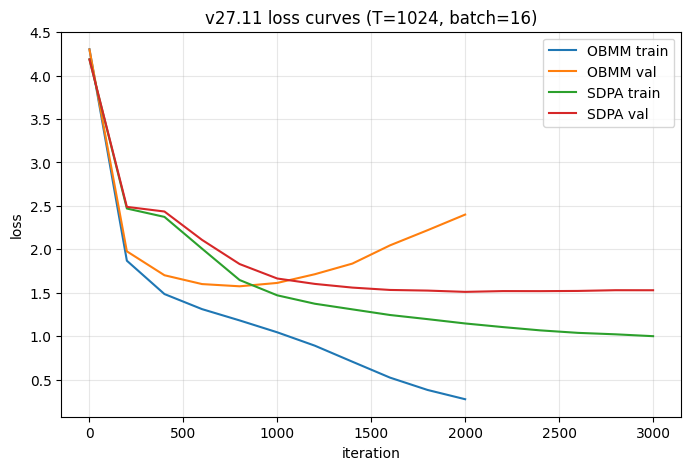

In [9]:
VERSION = globals().get("VERSION", "v27.11")
TAG = f"[{VERSION}]"


# =====================================================
# Train/Val loss curves (eval checkpoints)
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(obmm_hist["iter"], obmm_hist["train"], label="OBMM train")
plt.plot(obmm_hist["iter"], obmm_hist["val"],   label="OBMM val")

if run_baseline and sdpa_hist is not None:
    plt.plot(sdpa_hist["iter"], sdpa_hist["train"], label="SDPA train")
    plt.plot(sdpa_hist["iter"], sdpa_hist["val"],   label="SDPA val")

plt.xlabel("iteration")
plt.ylabel("loss")
plt.title(f"{VERSION} loss curves (T={block_size}, batch={batch_size})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [10]:

# =====================================================
# Sample generation (qualitative sanity)
# =====================================================

prompt = "ROMEO:"

print("\n--- OBMM sample ---")
out_ids = generate(obmm_model, encode(prompt), max_new_tokens=400, temperature=0.85, top_k=50)
print(decode(out_ids))

if run_baseline and sdpa_model is not None:
    print("\n--- SDPA baseline sample ---")
    out_ids = generate(sdpa_model, encode(prompt), max_new_tokens=400, temperature=0.85, top_k=50)
    print(decode(out_ids))



--- OBMM sample ---
ROMEO:
You will not fornic what a lovereign sick
By more here the nose bow's but straight me;
And by the deadly hadst not how make him.

NUCHESS OF YORK:
Why, when a came is lose is love and fall
For thou away the man, as we will not sit sit
The voling thy state and pleased in your son,
Not so your common, by your power of fly
That took not when my captive me ear a
mother in,
Leave the goes to tall him 

--- SDPA baseline sample ---
ROMEO:
Be gentleman, sir.

First Servant:
And to some well.

Second Servingman:
Faith, I am a person night: and by
too be drivines he business. The bastards. Good beats
unrestancies, when else this face and when
qeath what hath done for her should strokengthed in the dwell
she complixions to for and enjoys in her oath, sirrike
are her power with his scratch and blows with a field,
and his face off a lit


In [11]:
VERSION = globals().get("VERSION", "v27.11")
TAG = f"[{VERSION}]"

# =====================================================
# Speed microbenchmark (v27.11) — TRAIN-LIKE
# Issue B: benchmark matches training (depth, dropout, batch, grad-clip, opt.step)
# =====================================================

@torch.no_grad()
def _sync():
    if device == "cuda":
        torch.cuda.synchronize()


def bench_step_trainlike(attn_type: str, T: int, batch: int, iters: int = 10) -> float:
    """Average ms/iter for a full training step (fwd+bwd+opt.step), configured like training."""

    # Build a cfg that matches the training hyperparams as closely as possible,
    # except for sequence length T (we sweep T).
    cfg2 = make_cfg(attn_type, T=T)

    m = GPT(cfg2).to(device)
    m.train()

    opt = torch.optim.AdamW(m.parameters(), lr=learning_rate, weight_decay=weight_decay)
    autocast_b, scaler_b = get_amp(device)

    xb = torch.randint(0, vocab_size, (batch, T), device=device)
    yb = torch.randint(0, vocab_size, (batch, T), device=device)

    # -----------------------------
    # warmup (and assertions)
    # -----------------------------
    for _ in range(5):
        opt.zero_grad(set_to_none=True)
        if scaler_b is not None:
            with autocast_b():
                _, loss = m(xb, yb)
            assert loss.requires_grad, "bench_step_trainlike: loss does not require grad"
            assert torch.isfinite(loss).item(), f"bench_step_trainlike: loss not finite: {loss.item()}"
            scaler_b.scale(loss).backward()
            scaler_b.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(m.parameters(), grad_clip)

            # at least one grad
            got_grad = any(p.grad is not None for p in m.parameters())
            assert got_grad, "bench_step_trainlike: no parameter received gradients (warmup)"

            scaler_b.step(opt)
            scaler_b.update()
        else:
            _, loss = m(xb, yb)
            assert loss.requires_grad
            assert torch.isfinite(loss).item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), grad_clip)
            got_grad = any(p.grad is not None for p in m.parameters())
            assert got_grad, "bench_step_trainlike: no parameter received gradients (warmup)"
            opt.step()
    _sync()

    # -----------------------------
    # timed loop
    # -----------------------------
    t0 = time.time()
    for _ in range(iters):
        opt.zero_grad(set_to_none=True)
        if scaler_b is not None:
            with autocast_b():
                _, loss = m(xb, yb)
            scaler_b.scale(loss).backward()
            scaler_b.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(m.parameters(), grad_clip)
            scaler_b.step(opt)
            scaler_b.update()
        else:
            _, loss = m(xb, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), grad_clip)
            opt.step()
    _sync()

    return (time.time() - t0) * 1000.0 / iters


# -----------------------------------------
# Sweep T (train-like)
# -----------------------------------------
_FAST = bool(globals().get("FAST_DEV_RUN", False))
bench_Ts = [128, 256, 512, 1024, 2048, 4096]
bench_iters = 10
if _FAST:
    bench_Ts = [128, 256, 512]
    bench_iters = 2

print(f"\n{TAG} Train-like benchmark | OBMM_layers={n_layers_obmm} | SDPA_layers={n_layers_sdpa} | batch={batch_size} | dropout={obmm_cfg.dropout} | MODE={MODE}")
for T in bench_Ts:
    # Keep batch fixed up to the training context length; downscale for longer T to avoid OOM.
    bench_batch = batch_size if T <= block_size else max(1, int(batch_size * block_size // T))

    try:
        ms_obmm = bench_step_trainlike(attn_type_obmm, T, batch=bench_batch, iters=bench_iters)
    except RuntimeError as e:
        if device == "cuda" and "out of memory" in str(e).lower():
            print(f"T={T:4d} | OBMM OOM (batch={bench_batch})")
            torch.cuda.empty_cache()
            continue
        raise

    try:
        ms_sdpa = bench_step_trainlike(attn_type_sdpa, T, batch=bench_batch, iters=bench_iters)
    except RuntimeError as e:
        if device == "cuda" and "out of memory" in str(e).lower():
            print(f"T={T:4d} | SDPA OOM (batch={bench_batch})")
            torch.cuda.empty_cache()
            continue
        raise

    tok_per_s_obmm = (bench_batch * T) / (ms_obmm / 1000.0)
    tok_per_s_sdpa = (bench_batch * T) / (ms_sdpa / 1000.0)
    speedup = ms_sdpa / ms_obmm

    print(
        f"T={T:4d} | batch={bench_batch:3d} | OBMM {ms_obmm:7.2f} ms/iter ({tok_per_s_obmm:8.0f} tok/s) | "
        f"SDPA {ms_sdpa:7.2f} ms/iter ({tok_per_s_sdpa:8.0f} tok/s) | speedup {speedup:5.2f}x"
    )



[v27.11] Train-like benchmark | OBMM_layers=6 | SDPA_layers=6 | batch=16 | dropout=0.1 | MODE=soft4_grid32_hash1_counts_gated_msg48
T= 128 | batch= 16 | OBMM   55.30 ms/iter (   37034 tok/s) | SDPA   46.73 ms/iter (   43825 tok/s) | speedup  0.85x
T= 256 | batch= 16 | OBMM  121.17 ms/iter (   33804 tok/s) | SDPA   89.66 ms/iter (   45683 tok/s) | speedup  0.74x
T= 512 | batch= 16 | OBMM  250.04 ms/iter (   32763 tok/s) | SDPA  185.20 ms/iter (   44233 tok/s) | speedup  0.74x
T=1024 | batch= 16 | OBMM  533.48 ms/iter (   30712 tok/s) | SDPA  432.24 ms/iter (   37905 tok/s) | speedup  0.81x
T=2048 | batch=  8 | OBMM  615.44 ms/iter (   26622 tok/s) | SDPA  595.18 ms/iter (   27528 tok/s) | speedup  0.97x
T=4096 | batch=  4 | OBMM  835.10 ms/iter (   19619 tok/s) | SDPA 1020.10 ms/iter (   16061 tok/s) | speedup  1.22x
